In [3]:
import pandas as pd

C:\Users\HP\AppData\Roaming\Python\Python313\site-packages\pandas\core\computation\expressions.py:22: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.10.1' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED


### `Q-1:` You are given a Multi index DataFrame. You task is to swap level-0 index with level-0 column.
* Change Branch -> ('cse', 'ece') as columns at level-0 and ('delhi'	'mumbai') as level-0 Index
* And Sort on row index level-0

In [4]:
# Given Code Snippets
index_val = [('cse',2019),('cse',2020),('cse',2021),('cse',2022),('ece',2019),('ece',2020),('ece',2021),('ece',2022)]
multiindex = pd.MultiIndex.from_tuples(index_val)
df = pd.DataFrame(
    [
        [1,2,0,0],
        [3,4,0,0],
        [5,6,0,0],
        [7,8,0,0],
        [9,10,0,0],
        [11,12,0,0],
        [13,14,0,0],
        [15,16,0,0],
    ],
    index = multiindex,
    columns = pd.MultiIndex.from_product([['delhi','mumbai'],['avg_package','students']])
)

df

delhi               mumbai         
         avg_package students avg_package students
cse 2019           1        2           0        0
    2020           3        4           0        0
    2021           5        6           0        0
    2022           7        8           0        0
ece 2019           9       10           0        0
    2020          11       12           0        0
    2021          13       14           0        0
    2022          15       16           0        0

In [5]:
# code here
df.stack(level=0).unstack(0).swaplevel(axis=1).swaplevel(axis=0).sort_index(level=0)

cse         ece      cse      ece
            avg_package avg_package students students
delhi  2019           1           9        2       10
       2020           3          11        4       12
       2021           5          13        6       14
       2022           7          15        8       16
mumbai 2019           0           0        0        0
       2020           0           0        0        0
       2021           0           0        0        0
       2022           0           0        0        0

### `Q-2:` Covid Cases Data Set Problem
 Make a DataFrame Using both Covid Dataset. With Country name as Level-0 and Provinance/State as Level-1 Index and date, No of cases and No of Deaths as Columns.

In [6]:
confirm = pd.read_csv('https://docs.google.com/spreadsheets/d/e/2PACX-1vTmqT3kxd0i0RUFiEnwA1Hboiunv28MeNTatZsIEqlPPB7mHrl0ttJL7utZ23_1s5FW8ZjODmB8jHIi/pub?gid=2142019845&single=true&output=csv')

deaths = pd.read_csv("https://docs.google.com/spreadsheets/d/e/2PACX-1vQn4nLCKIVZMw4e89YeRqgKaSAAwRFaZ6ILMW_FUejZ2tkv3Np1f9gD4QOl3ASHeLzWjOjfmLDKcCOF/pub?gid=212966958&single=true&output=csv")

In [7]:
confirm = pd.read_csv("data/21_data/time_series_covid19_confirmed_global.csv")
deaths = pd.read_csv("data/21_data/time_series_covid19_deaths_global.csv")
confirm = confirm.melt(id_vars=["Province/State", "Country/Region", "Lat", "Long"], value_name="No_of_cases", var_name="Date")
deaths = deaths.melt(id_vars=["Province/State", "Country/Region", "Lat", "Long"], value_name="No_of_deaths", var_name="Date")
final = pd.merge(confirm, deaths, on=["Province/State", "Country/Region", "Lat", "Long", "Date"]).drop(columns=["Lat", "Long"]).set_index(keys=["Country/Region", "Province/State"])

### `Q-3:` Show Country with Heighest death percent out of confirmed Cases.

In [8]:
# code here
gr = final.reset_index().groupby("Country/Region")[["No_of_cases", "No_of_deaths"]].sum()
gr["percent"] = (gr["No_of_deaths"]/gr["No_of_cases"])*100

In [9]:
gr.sort_values(by='percent', ascending=False)

,No_of_cases,No_of_deaths,percent
Country/Region,,,
"Korea, North",234,1404,600.000000
MS Zaandam,9071,2014,22.202624
Yemen,7091065,1372952,19.361718
Sudan,38729339,2850576,7.360250
Peru,2203724423,156296296,7.092370
...,...,...,...
Antarctica,4235,0,0.000000
Holy See,24893,0,0.000000
Summer Olympics 2020,441598,0,0.000000


### `Q-4` : Make a dataframe for India from Covid Data with one extra column representing no of new cases.

* Just for Assumption "No of new cases" will be equal to difference of "no of cases" with previous day.
* First day new cases will be NaN or equal to no of cases

Say on 12/30/22 No of cases is - 44679608	and a day previous (12/29/22) no of cases is - 44679382.

Then for 12/30/22 -> No of New Cases  = 44679608 - 44679382 =

Note:- Try using shift Function

Try using the shift function

```
s = pd.Series([1,2,3,4,5,6])
s #-> [1,2,3,4,5,6]
s.shift(1) #-> [NaN, 1,2,3,4,5]
s.shift(-1) #-> [2,3,4,5,6, NaN]
```

In [17]:
# code here
dff = final.reset_index()
dff  = dff[dff["Country/Region"]=="India"]
dff["previous"] = dff["No_of_cases"].shift()
dff["increase"] = dff["No_of_cases"]-dff["previous"]
dff

,Country/Region,Province/State,Date,No_of_cases,No_of_deaths,previous,increase
148,India,NaN,1/22/20,0,0,NaN,NaN
437,India,NaN,1/23/20,0,0,0.0,0.0
726,India,NaN,1/24/20,0,0,0.0,0.0
1015,India,NaN,1/25/20,0,0,0.0,0.0
1304,India,NaN,1/26/20,0,0,0.0,0.0
...,...,...,...,...,...,...,...
309956,India,NaN,12/29/22,44679382,530699,44679139.0,243.0
310245,India,NaN,12/30/22,44679608,530702,44679382.0,226.0
310534,India,NaN,12/31/22,44679873,530705,44679608.0,265.0
310823,India,NaN,1/1/23,44680046,530707,44679873.0,173.0


### `Q-5:` Read the Dataset using the below given link and create a multi-index dataframe using the columns "Country" and "City/Town".

This dataset is about the most polluted cities in the world. You can get details from [here](https://www.kaggle.com/datasets/rajkumarpandey02/worlds-most-air-polluted-countries-cities).

**Dataset link:** https://tinyurl.com/2fe6vz4u Directly use this link to read.

**Task:**
1. Find out the name of the city of India which is most poluted based on PM10.
2. Find out the name of the city of India which has minumum pollution level based on PM10.
3. Do same operations (like 1 and 2) with the country China.
4. Make a pie chart based on the column "PM10" of the country Poland.
5. Make a bar chart based on the columns "PM2.5" and "PM10" of the countries Israel and Qatar.
6. Convert this MultiIndex DataFrame to Series by retaining the informations.

In [23]:
# code

df = pd.read_csv("data/21_data/List of most-polluted cities by particulate matter concentration - List of most-polluted cities by particulate matter concentration.csv")

fil = df[df["Country"]=="India"]
fil.nlargest(1, "PM10")

,Unnamed: 0,Position,Country,City/Town,Year,PM2.5,Temporal coverage,PM10,Temporal coverage.1,Database version (year)
0,0,1,India,Kanpur,2016,173,>75%,319,NaN,2018


In [ ]:
fil.nsmallest(1, "PM10")

,Unnamed: 0,Position,Country,City/Town,Year,PM2.5,Temporal coverage,PM10,Temporal coverage.1,Database version (year)
483,483,484,India,Aizawl,2016,27,NaN,44,NaN,2018


In [ ]:
fils = df[df["Country"]=="China"]
fils.nlargest(1, "PM10")


,Unnamed: 0,Position,Country,City/Town,Year,PM2.5,Temporal coverage,PM10,Temporal coverage.1,Database version (year)
476,476,477,China,Anshun,2016,27,NaN,38,NaN,2018


In [31]:
fils.nsmallest(1, "PM10")

,Unnamed: 0,Position,Country,City/Town,Year,PM2.5,Temporal coverage,PM10,Temporal coverage.1,Database version (year)
476,476,477,China,Anshun,2016,27,NaN,38,NaN,2018


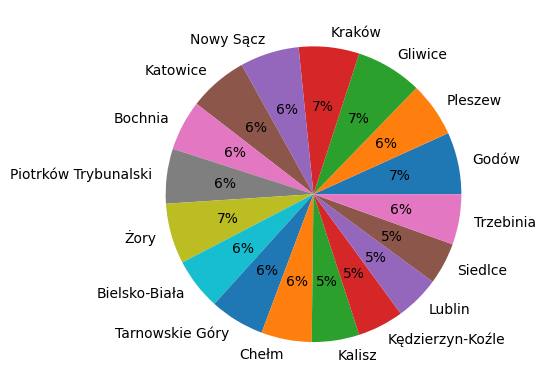

In [45]:
import matplotlib.pyplot as plt
f = df[df["Country"]=="Poland"][["City/Town", "PM10"]]
plt.pie(f["PM10"] ,labels=f["City/Town"], autopct="%1.f%%")
plt.show()

In [49]:
f["per"]=(f['PM10']/f["PM10"].sum())*100
f

,City/Town,PM10,per
370,Godów,43,6.771654
371,Pleszew,38,5.984252
392,Gliwice,46,7.244094
404,Kraków,42,6.614173
405,Nowy Sącz,41,6.456693
425,Katowice,41,6.456693
446,Bochnia,35,5.511811
447,Piotrków Trybunalski,38,5.984252
448,Żory,42,6.614173
471,Bielsko-Biała,36,5.669291


<Axes: xlabel='Country'>

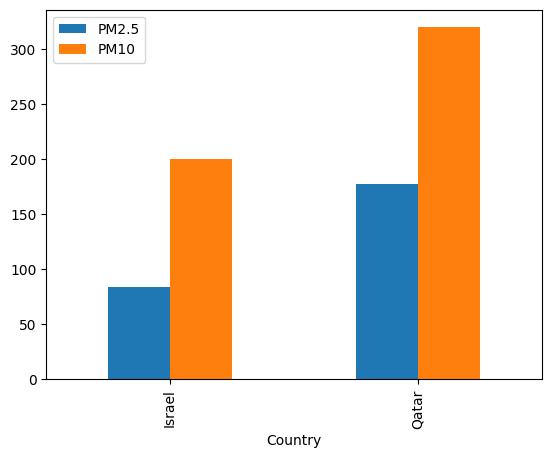

In [61]:
df[df["Country"].isin(["Israel", "Qatar"])].groupby("Country")[["PM2.5", "PM10"]].sum().plot(kind='bar')


In [69]:
df.stack()

0    Unnamed: 0                      0
     Position                        1
     Country                     India
     City/Town                  Kanpur
     Year                         2016
                                 ...  
499  PM2.5                          27
     Temporal coverage            >75%
     PM10                           56
     Temporal coverage.1          >75%
     Database version (year)      2018
Length: 5000, dtype: object